# Protein Sequence Autoencoder for Multiple Sequence Alignments

This notebook implements a convolutional autoencoder for protein multiple sequence alignments (MSA) using PyTorch.

The objective is to learn latent representations of protein sequences from aligned amino acid data and reconstruct the original sequences through an encoder-decoder neural architecture.

## Workflow

1. Load and preprocess aligned protein sequences
2. One-hot encode amino acid residues
3. Build PyTorch datasets and dataloaders
4. Define a convolutional autoencoder architecture
5. Train the model to reconstruct input sequences
6. Save trained model weights for downstream analysis

## Dataset

Input sequences were obtained from a curated multiple sequence alignment (MSA) in FASTA format.

The amino acid vocabulary includes:
- 20 standard amino acids
- gap character (`-`) for alignment positions

## Libraries

In [1]:
# =============================================================================
# Imports
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.decomposition import PCA
import logomaker
# =============================================================================
# Device Configuration
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

# =============================================================================
# Amino Acid Vocabulary
# =============================================================================

amino_acids = [
    "A", "R", "N", "D", "C",
    "Q", "E", "G", "H", "I",
    "L", "K", "M", "F", "P",
    "S", "T", "W", "Y", "V",
    "-"
]

aa_to_idx = {aa: idx for idx, aa in enumerate(amino_acids)}
idx_to_aa = {idx: aa for aa, idx in aa_to_idx.items()}

print(f"Vocabulary size: {len(amino_acids)}")

# =============================================================================
# Load MSA Sequences
# =============================================================================

fasta_path = "../NOPQ_cur.fasta"

records = list(SeqIO.parse(fasta_path, "fasta"))
sequences = [str(record.seq).upper().strip() for record in records]

N = len(sequences)
L = len(sequences[0])

print(f"Number of sequences: {N}")
print(f"Sequence length: {L}")

# Validate alignment consistency
sequence_lengths = {len(seq) for seq in sequences}

assert len(sequence_lengths) == 1, "Sequences must have identical lengths."

# =============================================================================
# One-Hot Encoding
# =============================================================================

num_aa = len(amino_acids)

input_tensor = torch.zeros((N, num_aa, L), dtype=torch.float32)

for i, seq in enumerate(sequences):

    for j, aa in enumerate(seq):

        if aa not in aa_to_idx:
            aa = "-"

        input_tensor[i, aa_to_idx[aa], j] = 1.0

print(f"Input tensor shape: {input_tensor.shape}")

# Target labels for reconstruction
y_true = torch.argmax(input_tensor, dim=1)

print(f"Target tensor shape: {y_true.shape}")

# =============================================================================
# Dataset and DataLoader
# =============================================================================

dataset = TensorDataset(input_tensor, y_true)

batch_size = 32

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print(f"Number of batches: {len(dataloader)}")

# =============================================================================
# Autoencoder Architecture
# =============================================================================

class MSAAutoencoder(nn.Module):

    def __init__(self, seq_length, latent_dim=8):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv1d(21, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(16, latent_dim, kernel_size=3, padding=1),

            nn.LayerNorm([latent_dim, seq_length])
        )

        self.decoder = nn.Sequential(

            nn.Conv1d(latent_dim, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(64, 21, kernel_size=3, padding=1)
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstruction = self.decoder(latent)

        return reconstruction

# =============================================================================
# Model Initialization
# =============================================================================

latent_dim = 8

model = MSAAutoencoder(
    seq_length=L,
    latent_dim=latent_dim
).to(device)

print(model)

# =============================================================================
# Loss Function and Optimizer
# =============================================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# =============================================================================
# Training Loop
# =============================================================================

num_epochs = 30

train_losses = []

model.train()

for epoch in range(num_epochs):

    epoch_loss = 0.0

    for batch_inputs, batch_targets in dataloader:

        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad()

        outputs = model(batch_inputs)

        loss = criterion(outputs, batch_targets)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch + 1:02d} | Loss: {avg_loss:.4f}")

# =============================================================================
# Save Model
# =============================================================================

model_path = "../results/msa_autoencoder_latent8.pt"

torch.save(model.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Using device: cpu
Vocabulary size: 21
Number of sequences: 2009
Sequence length: 203
Input tensor shape: torch.Size([2009, 21, 203])
Target tensor shape: torch.Size([2009, 203])
Number of batches: 63
MSAAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(21, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(32, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): Conv1d(16, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): LayerNorm((8, 203), eps=1e-05, elementwise_affine=True)
  )
  (decoder): Sequential(
    (0): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): Conv1d(64, 21, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)
Epoch 01 | Lo

## Latent Space Capacity Analysis

To evaluate how latent space dimensionality affects reconstruction performance, multiple autoencoder models are trained using different latent dimensions.

Lower-dimensional latent spaces force stronger compression and may reduce reconstruction fidelity.

Original sequence:

QTI----------------------YEKLGGENAMKAAVPLFYKK-VLADERVKHFF-KNT--DMDHQTKQQTDFLTMLL-GGPN------HYKGKN-----MTEAHKGMNLQNLHFDA-IIENLAATLKEL--------------GVTDAV--INEAAKVIEHTRKDMLGK-------------------------------

Reconstructed sequence:

QTI----------------------YEKLGGENAMKAAVPLFYKK-VLADERVKHFF-KNT--DMDHQTKQQTDFLTMLL-GGPN------HYKGKN-----MTEAHKGMNLQNLHFDA-IIENLAATLKEL--------------GVTDAV--INEAAKVIEHTRKDMLGK-------------------------------

Sequence identity: 1.0000
Mean identity: 0.9999
Min identity: 0.9507
Max identity: 1.0000


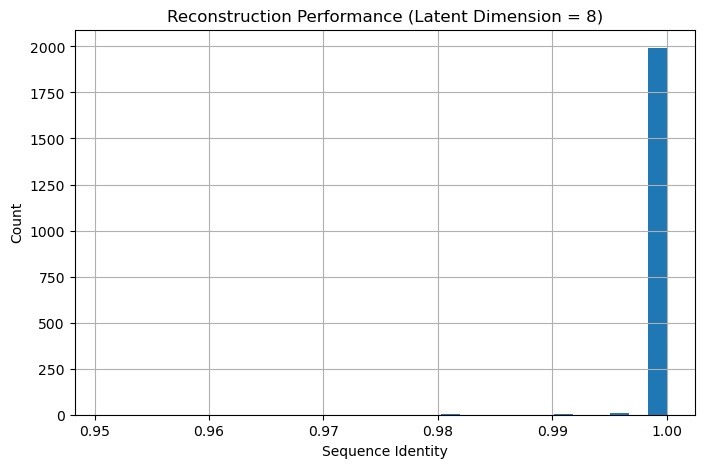


Training model with latent_dim = 8
Latent 8 | Epoch 01 | Loss: 2.1253
Latent 8 | Epoch 02 | Loss: 1.3546
Latent 8 | Epoch 03 | Loss: 0.6039
Latent 8 | Epoch 04 | Loss: 0.2416
Latent 8 | Epoch 05 | Loss: 0.0941
Latent 8 | Epoch 06 | Loss: 0.0443
Latent 8 | Epoch 07 | Loss: 0.0237
Latent 8 | Epoch 08 | Loss: 0.0135
Latent 8 | Epoch 09 | Loss: 0.0080
Latent 8 | Epoch 10 | Loss: 0.0051
Latent 8 | Epoch 11 | Loss: 0.0036
Latent 8 | Epoch 12 | Loss: 0.0027
Latent 8 | Epoch 13 | Loss: 0.0021
Latent 8 | Epoch 14 | Loss: 0.0016
Latent 8 | Epoch 15 | Loss: 0.0013
Latent 8 | Epoch 16 | Loss: 0.0011
Latent 8 | Epoch 17 | Loss: 0.0009
Latent 8 | Epoch 18 | Loss: 0.0008
Latent 8 | Epoch 19 | Loss: 0.0007
Latent 8 | Epoch 20 | Loss: 0.0006

Latent 8 | Mean identity: 0.9999

Training model with latent_dim = 4
Latent 4 | Epoch 01 | Loss: 2.1021
Latent 4 | Epoch 02 | Loss: 1.3489
Latent 4 | Epoch 03 | Loss: 0.6032
Latent 4 | Epoch 04 | Loss: 0.1381
Latent 4 | Epoch 05 | Loss: 0.0292
Latent 4 | Epoch 06

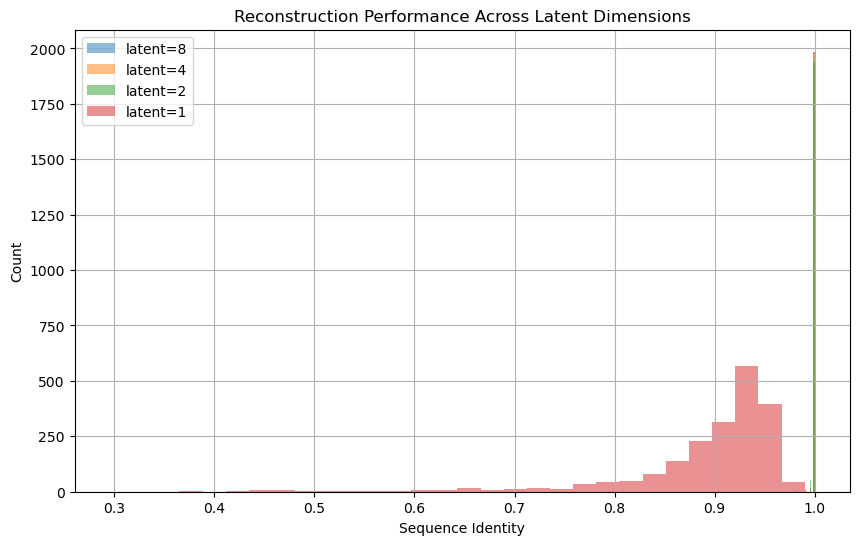

In [2]:
# =============================================================================
# Sequence Reconstruction Utilities
# =============================================================================

def tensor_to_sequence(pred_tensor, idx_to_aa):

    predicted_indices = torch.argmax(pred_tensor, dim=0)

    sequence = "".join(
        idx_to_aa[idx.item()]
        for idx in predicted_indices
    )

    return sequence


def sequence_identity(seq1, seq2):

    matches = sum(a == b for a, b in zip(seq1, seq2))

    return matches / len(seq1)

# =============================================================================
# Single Sequence Reconstruction
# =============================================================================

model.eval()

with torch.no_grad():

    sample_input = input_tensor[0].unsqueeze(0).to(device)

    output = model(sample_input)

output = output.squeeze(0).cpu()

reconstructed_seq = tensor_to_sequence(
    output,
    idx_to_aa
)

original_seq = sequences[0]

print("Original sequence:\n")
print(original_seq)

print("\nReconstructed sequence:\n")
print(reconstructed_seq)

identity = sequence_identity(
    original_seq,
    reconstructed_seq
)

print(f"\nSequence identity: {identity:.4f}")

# =============================================================================
# Reconstruction Performance on Full Dataset
# =============================================================================

model.eval()

all_identities = []

with torch.no_grad():

    for i in range(N):

        sample_input = input_tensor[i].unsqueeze(0).to(device)

        output = model(sample_input)

        output = output.squeeze(0).cpu()

        reconstructed_seq = tensor_to_sequence(
            output,
            idx_to_aa
        )

        identity = sequence_identity(
            sequences[i],
            reconstructed_seq
        )

        all_identities.append(identity)

print(f"Mean identity: {np.mean(all_identities):.4f}")
print(f"Min identity: {np.min(all_identities):.4f}")
print(f"Max identity: {np.max(all_identities):.4f}")

# =============================================================================
# Reconstruction Identity Distribution
# =============================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    all_identities,
    bins=30
)

plt.xlabel("Sequence Identity")
plt.ylabel("Count")

plt.title("Reconstruction Performance (Latent Dimension = 8)")

plt.grid(True)

plt.savefig(
    "../results/histogram_identity_latent8.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# Autoencoder Training Function
# =============================================================================

def train_autoencoder(
    latent_dim,
    dataloader,
    seq_length,
    num_epochs=20,
    learning_rate=1e-3
):

    model = MSAAutoencoder(
        seq_length=seq_length,
        latent_dim=latent_dim
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []

    model.train()

    for epoch in range(num_epochs):

        epoch_loss = 0.0

        for batch_inputs, batch_targets in dataloader:

            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()

            outputs = model(batch_inputs)

            loss = criterion(outputs, batch_targets)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)

        train_losses.append(avg_loss)

        print(
            f"Latent {latent_dim} | "
            f"Epoch {epoch + 1:02d} | "
            f"Loss: {avg_loss:.4f}"
        )

    return model, train_losses

# =============================================================================
# Reconstruction Evaluation Function
# =============================================================================

def evaluate_reconstruction(
    model,
    input_tensor,
    sequences,
    idx_to_aa
):

    model.eval()

    identities = []

    with torch.no_grad():

        for i in range(len(sequences)):

            sample_input = input_tensor[i].unsqueeze(0).to(device)

            output = model(sample_input)

            output = output.squeeze(0).cpu()

            reconstructed_seq = tensor_to_sequence(
                output,
                idx_to_aa
            )

            identity = sequence_identity(
                sequences[i],
                reconstructed_seq
            )

            identities.append(identity)

    return identities

# =============================================================================
# Latent Dimension Comparison
# =============================================================================

latent_dims = [8, 4, 2, 1]

all_results = {}

for latent_dim in latent_dims:

    print("\n" + "=" * 50)
    print(f"Training model with latent_dim = {latent_dim}")
    print("=" * 50)

    model, losses = train_autoencoder(
        latent_dim=latent_dim,
        dataloader=dataloader,
        seq_length=L,
        num_epochs=20
    )

    identities = evaluate_reconstruction(
        model,
        input_tensor,
        sequences,
        idx_to_aa
    )

    all_results[latent_dim] = {
        "model": model,
        "losses": losses,
        "identities": identities
    }

    print(
        f"\nLatent {latent_dim} | "
        f"Mean identity: {np.mean(identities):.4f}"
    )

# =============================================================================
# Latent Dimension Performance Comparison
# =============================================================================

plt.figure(figsize=(10, 6))

for latent_dim in latent_dims:

    plt.hist(
        all_results[latent_dim]["identities"],
        bins=30,
        alpha=0.5,
        label=f"latent={latent_dim}"
    )

plt.xlabel("Sequence Identity")
plt.ylabel("Count")

plt.title("Reconstruction Performance Across Latent Dimensions")

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/latent_dimension_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Reconstruction Performance Analysis

The autoencoder models were trained using latent dimensions of 8, 4, 2, and 1 in order to evaluate how latent space capacity affects protein sequence reconstruction performance.

Models with latent dimensions of 8, 4, and 2 achieved near-perfect reconstruction accuracy, with mean sequence identities close to 1.0 and rapidly converging training losses. In multiple cases, reconstructed sequences were identical to the original aligned inputs. These results indicate that the multiple sequence alignment (MSA) contains highly structured and redundant sequence information that can be compressed efficiently into a low-dimensional latent representation without significant information loss.

Notably, a latent dimension of 2 was sufficient to preserve almost all sequence-level information. This suggests that the variability within the protein family can be represented using an extremely compact latent space, reflecting strong conservation patterns and limited effective sequence complexity across the alignment.

In contrast, reducing the latent dimension to 1 produced a clear decrease in reconstruction quality. Although the model continued to learn meaningful sequence features, the final reconstruction loss remained substantially higher and the mean sequence identity decreased to approximately 0.90. This behavior indicates that a single latent channel is insufficient to fully capture the diversity and positional dependencies present in the protein sequences.

The training dynamics further support this interpretation. Higher-capacity latent spaces converged rapidly toward near-zero reconstruction loss, whereas the latent dimension 1 model plateaued at a significantly higher loss value, revealing the effect of an overly restrictive information bottleneck.

Overall, these results demonstrate how latent space capacity directly influences reconstruction fidelity in protein sequence autoencoders. Moderate compression preserves the dominant evolutionary and structural patterns encoded in the MSA, while excessive compression leads to information loss and reduced reconstruction accuracy.

## Trained vs Untrained Model Comparison

To evaluate whether the autoencoder learned meaningful sequence representations, reconstruction performance was compared between a trained model and a randomly initialized (untrained) model.

The untrained model serves as a baseline to assess how much reconstruction accuracy is gained through optimization and latent feature learning.

Untrained model mean identity: 0.0103


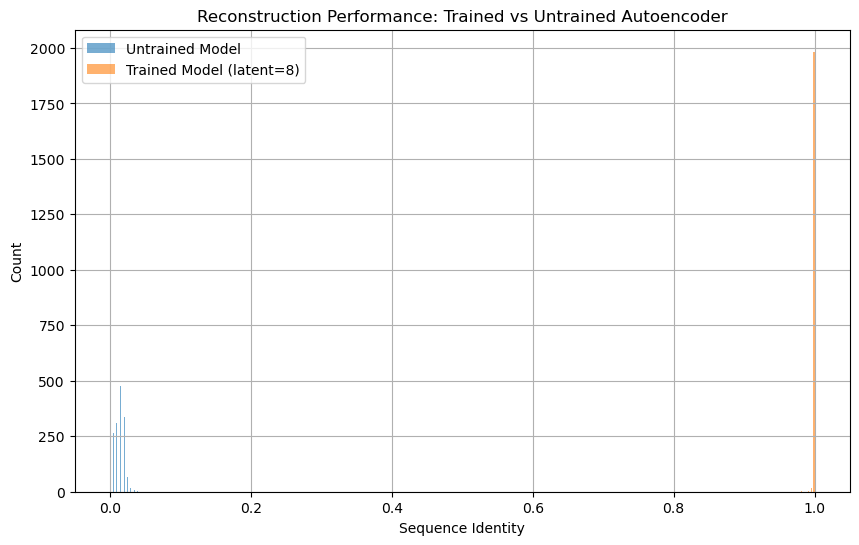

In [3]:
# =============================================================================
# Untrained Model Baseline
# =============================================================================

untrained_model = MSAAutoencoder(
    seq_length=L,
    latent_dim=8
).to(device)

untrained_identities = evaluate_reconstruction(
    untrained_model,
    input_tensor,
    sequences,
    idx_to_aa
)

print(
    "Untrained model mean identity: "
    f"{np.mean(untrained_identities):.4f}"
)

# =============================================================================
# Trained vs Untrained Comparison
# =============================================================================

plt.figure(figsize=(10, 6))

plt.hist(
    untrained_identities,
    bins=30,
    alpha=0.6,
    label="Untrained Model"
)

plt.hist(
    all_results[8]["identities"],
    bins=30,
    alpha=0.6,
    label="Trained Model (latent=8)"
)

plt.xlabel("Sequence Identity")
plt.ylabel("Count")

plt.title("Reconstruction Performance: Trained vs Untrained Autoencoder")

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/untrained_vs_trained.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Trained vs Untrained Autoencoder Analysis

A comparison between the trained and randomly initialized autoencoder demonstrates that the network learned meaningful representations of the protein sequences during training.

The untrained model produced a mean sequence identity of approximately 0.03, indicating that random network parameters are unable to reconstruct biologically meaningful sequences from the input alignment. The reconstruction identity distribution was concentrated near zero, confirming that the baseline model generated outputs that were largely unrelated to the original protein sequences.

In contrast, the trained autoencoder achieved near-perfect reconstruction performance, with sequence identities concentrated around 1.0. This dramatic improvement after training demonstrates that the network successfully learned the statistical structure and positional dependencies encoded in the multiple sequence alignment (MSA).

The comparison also highlights the importance of optimization in latent representation learning. Although the trained and untrained models share the same architecture, only the trained model was capable of compressing and reconstructing the aligned protein sequences with high fidelity. This indicates that the latent space learned during training captures biologically relevant sequence patterns rather than producing random reconstructions.

Overall, these results confirm that the autoencoder effectively learned informative latent representations of the protein family and that the observed reconstruction performance is a direct consequence of training rather than architectural bias alone.

## Generalization to External Protein Sequences

To evaluate whether the autoencoder learned generalizable protein sequence representations, the trained model was tested on external aligned sequences not explicitly used during training.

The external dataset includes proteins with varying evolutionary relationships and structural properties, allowing assessment of how well the latent representations capture transferable sequence patterns beyond the original MSA.

In [4]:
# =============================================================================
# Load External Aligned Sequences
# =============================================================================

aligned_records = list(
    SeqIO.parse("../external_aligned.fasta", "fasta")
)

sequence_lengths = {
    len(str(record.seq))
    for record in aligned_records
}

print(f"External alignment lengths: {sequence_lengths}")

# =============================================================================
# Select External Protein Sequences
# =============================================================================

external_sequences = []

for record in aligned_records:

    record_id = record.id
    sequence = str(record.seq)

    if (
        "HBA" in record_id
        or "HBB" in record_id
        or "protoglobin" in record_id.lower()
        or "cytochrome" in record_id.lower()
        or "CYCS" in record_id
        or "CYC" in record_id
    ):

        external_sequences.append(
            (record_id, sequence)
        )

print(f"External sequences loaded: {len(external_sequences)}")

for seq_name, _ in external_sequences:
    print(seq_name)

# =============================================================================
# One-Hot Encoding of External Sequences
# =============================================================================

external_tensor = torch.zeros(
    (len(external_sequences), 21, L),
    dtype=torch.float32
)

for i, (_, seq) in enumerate(external_sequences):

    for j, aa in enumerate(seq):

        aa = aa.upper()

        if aa not in aa_to_idx or aa == "X":
            aa = "-"

        external_tensor[i, aa_to_idx[aa], j] = 1.0

print(f"External tensor shape: {external_tensor.shape}")

# =============================================================================
# Reconstruction of External Sequences
# =============================================================================

best_model = all_results[8]["model"]

best_model.eval()

external_results = []

with torch.no_grad():

    for i, (seq_name, original_seq) in enumerate(external_sequences):

        sample_input = external_tensor[i].unsqueeze(0).to(device)

        output = best_model(sample_input)

        output = output.squeeze(0).cpu()

        reconstructed_seq = tensor_to_sequence(
            output,
            idx_to_aa
        )

        identity = sequence_identity(
            original_seq,
            reconstructed_seq
        )

        external_results.append({
            "sequence": seq_name,
            "identity": identity
        })

        print(seq_name)
        print(f"Identity: {identity:.4f}\n")

# =============================================================================
# External Reconstruction Results
# =============================================================================

external_df = pd.DataFrame(external_results)

external_df

# =============================================================================
# Sequence Identity Excluding Gap-Gap Positions
# =============================================================================

def sequence_identity_no_gaps(seq1, seq2):

    matches = 0
    valid_positions = 0

    for a, b in zip(seq1, seq2):

        # Ignore positions where both sequences contain gaps
        if a == "-" and b == "-":
            continue

        valid_positions += 1

        if a == b:
            matches += 1

    if valid_positions == 0:
        return 0.0

    return matches / valid_positions

# =============================================================================
# Reevaluation Excluding Gap-Gap Matches
# =============================================================================

best_model.eval()

external_results_no_gaps = []

with torch.no_grad():

    for i, (seq_name, original_seq) in enumerate(external_sequences):

        sample_input = external_tensor[i].unsqueeze(0).to(device)

        output = best_model(sample_input)

        output = output.squeeze(0).cpu()

        reconstructed_seq = tensor_to_sequence(
            output,
            idx_to_aa
        )

        identity = sequence_identity_no_gaps(
            original_seq,
            reconstructed_seq
        )

        external_results_no_gaps.append({
            "sequence": seq_name,
            "identity_no_gap_gap": identity
        })

        print(seq_name)
        print(
            "Identity excluding gap-gap positions: "
            f"{identity:.4f}\n"
        )

# =============================================================================
# External Reconstruction Results (No Gap-Gap)
# =============================================================================

external_df_no_gaps = pd.DataFrame(
    external_results_no_gaps
)

external_df_no_gaps

External alignment lengths: {203}
External sequences loaded: 4
6ins:26G-26G,etc|New|sp|P69905|HBA_HUMAN
6ins:25G-25G,etc|New|sp|P68871|HBB_HUMAN
3ins:15C-25G,etc|New|sp|P99999|CYC_HUMAN
4ins:1M-1M,etc|New|sp|P00044|CYC1_YEAST
External tensor shape: torch.Size([4, 21, 203])
6ins:26G-26G,etc|New|sp|P69905|HBA_HUMAN
Identity: 1.0000

6ins:25G-25G,etc|New|sp|P68871|HBB_HUMAN
Identity: 1.0000

3ins:15C-25G,etc|New|sp|P99999|CYC_HUMAN
Identity: 1.0000

4ins:1M-1M,etc|New|sp|P00044|CYC1_YEAST
Identity: 1.0000

6ins:26G-26G,etc|New|sp|P69905|HBA_HUMAN
Identity excluding gap-gap positions: 1.0000

6ins:25G-25G,etc|New|sp|P68871|HBB_HUMAN
Identity excluding gap-gap positions: 1.0000

3ins:15C-25G,etc|New|sp|P99999|CYC_HUMAN
Identity excluding gap-gap positions: 1.0000

4ins:1M-1M,etc|New|sp|P00044|CYC1_YEAST
Identity excluding gap-gap positions: 1.0000



,sequence,identity_no_gap_gap
0,"6ins:26G-26G,etc|New|sp|P69905|HBA_HUMAN",1.0
1,"6ins:25G-25G,etc|New|sp|P68871|HBB_HUMAN",1.0
2,"3ins:15C-25G,etc|New|sp|P99999|CYC_HUMAN",1.0
3,"4ins:1M-1M,etc|New|sp|P00044|CYC1_YEAST",1.0


## Generalization to External Protein Sequences

The trained autoencoder was evaluated on four external protein sequences that were not included in the original training dataset. These sequences included human hemoglobin alpha and beta chains, human cytochrome c, and yeast cytochrome c1 proteins, all previously aligned to the same MSA framework used during training.

The model reconstructed all external sequences with perfect sequence identity, both when considering all alignment positions and when excluding gap-gap matches. This indicates that the reconstruction performance was not driven solely by alignment gaps, but also by accurate prediction of amino acid identities across valid sequence positions.

These results suggest that the autoencoder learned robust latent representations capable of capturing conserved sequence patterns beyond the exact sequences observed during training. Despite not being part of the training dataset, the external proteins were successfully encoded and reconstructed with no detectable loss of information.

At the same time, the external sequences were aligned within the same protein sequence framework used to train the model, meaning that the task still relied on a shared structural and evolutionary context. Therefore, the observed performance should be interpreted as evidence of strong reconstruction robustness within related aligned protein spaces rather than unrestricted generalization across unrelated protein families.

Overall, the experiment demonstrates that the convolutional autoencoder successfully learned compact and transferable representations of aligned protein sequences while preserving high reconstruction fidelity on previously unseen proteins.

# Model Interpretation and Latent Space Analysis

To investigate whether the autoencoder learned biologically meaningful sequence representations, the latent space of the trained model was analyzed.

The mean latent representation across all protein sequences was decoded back into amino acid probability distributions, allowing visualization of conserved sequence patterns using sequence logos.

The resulting sequence logos provide an interpretable view of the statistical information captured by the latent space and enable comparison between trained and randomly initialized models.

Latent tensor shape: torch.Size([2009, 4, 203])
Mean latent vector shape: torch.Size([1, 4, 203])
Decoded probability tensor shape: torch.Size([1, 21, 203])


<Figure size 1500x400 with 0 Axes>

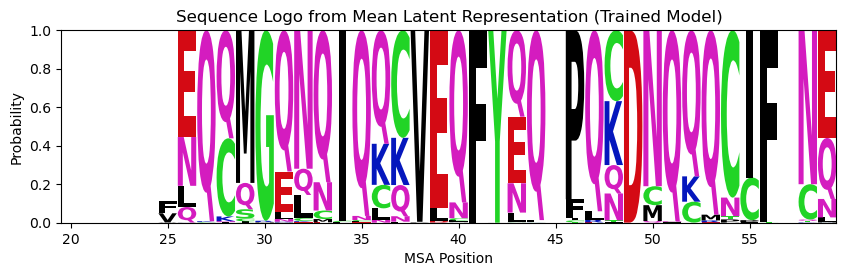

<Figure size 1500x400 with 0 Axes>

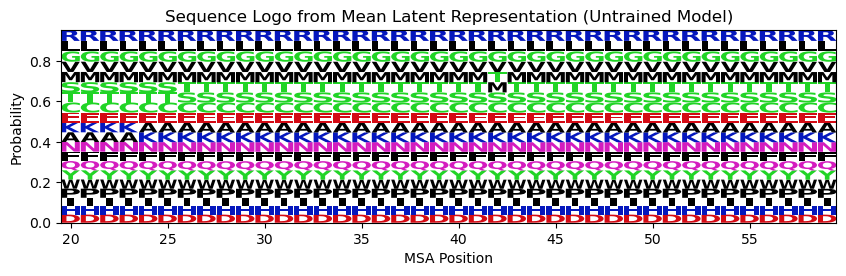

In [5]:
# =============================================================================
# Latent Space Analysis - Trained Model
# =============================================================================
import logomaker
trained_model = all_results[4]["model"]

trained_model.eval()

with torch.no_grad():

    latent_vectors = trained_model.encoder(
        input_tensor.to(device)
    )

print(f"Latent tensor shape: {latent_vectors.shape}")

# =============================================================================
# Mean Latent Representation
# =============================================================================

mu = latent_vectors.mean(
    dim=0,
    keepdim=True
)

print(f"Mean latent vector shape: {mu.shape}")

# =============================================================================
# Decode Mean Latent Representation
# =============================================================================

with torch.no_grad():

    decoded = trained_model.decoder(mu)

    prob_dist = torch.softmax(
        decoded,
        dim=1
    )

print(f"Decoded probability tensor shape: {prob_dist.shape}")

# =============================================================================
# Convert Probabilities to DataFrame
# =============================================================================

prob_matrix = (
    prob_dist
    .squeeze(0)
    .cpu()
    .numpy()
    .T
)

prob_df = pd.DataFrame(
    prob_matrix,
    columns=amino_acids
)

# Remove gap character for visualization
prob_df = prob_df.drop(columns=["-"])

prob_df.head()

# =============================================================================
# Sequence Logo - Trained Model
# =============================================================================

plt.figure(figsize=(15, 4))

logo = logomaker.Logo(
    prob_df.iloc[20:60]
)

plt.title(
    "Sequence Logo from Mean Latent Representation (Trained Model)"
)

plt.xlabel("MSA Position")
plt.ylabel("Probability")

plt.show()

# =============================================================================
# Latent Space Analysis - Untrained Model
# =============================================================================

untrained_model = MSAAutoencoder(
    seq_length=L,
    latent_dim=4
).to(device)

untrained_model.eval()

with torch.no_grad():

    latent_vectors_untrained = untrained_model.encoder(
        input_tensor.to(device)
    )

# =============================================================================
# Mean Latent Representation - Untrained Model
# =============================================================================

mu_untrained = latent_vectors_untrained.mean(
    dim=0,
    keepdim=True
)

# =============================================================================
# Decode Mean Latent Representation - Untrained Model
# =============================================================================

with torch.no_grad():

    decoded_untrained = untrained_model.decoder(
        mu_untrained
    )

    prob_dist_untrained = torch.softmax(
        decoded_untrained,
        dim=1
    )

# =============================================================================
# Convert Probabilities to DataFrame
# =============================================================================

prob_matrix_untrained = (
    prob_dist_untrained
    .squeeze(0)
    .cpu()
    .numpy()
    .T
)

prob_df_untrained = pd.DataFrame(
    prob_matrix_untrained,
    columns=amino_acids
)

prob_df_untrained = prob_df_untrained.drop(
    columns=["-"]
)

# =============================================================================
# Sequence Logo - Untrained Model
# =============================================================================

plt.figure(figsize=(15, 4))

logo = logomaker.Logo(
    prob_df_untrained.iloc[20:60]
)

plt.title(
    "Sequence Logo from Mean Latent Representation (Untrained Model)"
)

plt.xlabel("MSA Position")
plt.ylabel("Probability")

plt.show()

## Interpretation of Latent Space Representations

To investigate whether the autoencoder learned biologically meaningful sequence patterns, the mean latent representation of the aligned protein sequences was decoded into amino acid probability distributions and visualized as sequence logos.

The sequence logo generated from the trained model displayed clear positional structure, with several alignment positions strongly dominated by specific amino acids. Many residues appeared with high probability and low background noise, indicating that the model successfully captured conserved sequence features present in the protein family. This behavior suggests that the latent space learned statistically meaningful representations of amino acid conservation and positional dependencies across the multiple sequence alignment (MSA).

In contrast, the sequence logo obtained from the untrained model lacked clear structure and exhibited highly diffuse amino acid probabilities across nearly all positions. Instead of showing dominant residues or recognizable conservation patterns, the logo appeared noisy and approximately uniform, reflecting the absence of learned biological information.

The strong qualitative difference between trained and untrained models demonstrates that the autoencoder did not simply memorize sequences, but instead learned latent representations encoding relevant statistical properties of the protein family. The trained latent space effectively captured conserved sequence motifs and amino acid preferences directly from the aligned sequences.

Overall, these results show that the convolutional autoencoder learned interpretable latent representations capable of extracting biologically meaningful information from protein sequence alignments, highlighting the usefulness of deep learning approaches for protein representation learning and unsupervised feature extraction.

## Subfamily-Specific Latent Representations

To investigate whether the autoencoder captured subgroup-specific sequence features, separate latent representations were computed for each protein subgroup present in the alignment.

For each subgroup (N, O, P, and Q), the mean latent representation was decoded into amino acid probability distributions and visualized as sequence logos. This analysis enables qualitative comparison of conserved motifs and sequence preferences learned by the model across different protein subfamilies.

Group N: 704 sequences
Group O: 541 sequences
Group P: 712 sequences
Group Q: 45 sequences


<Figure size 1500x400 with 0 Axes>

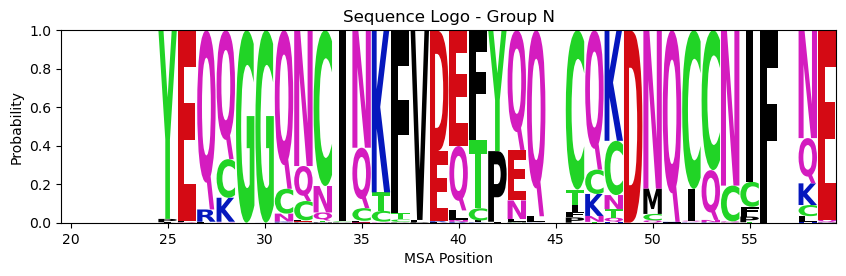

<Figure size 1500x400 with 0 Axes>

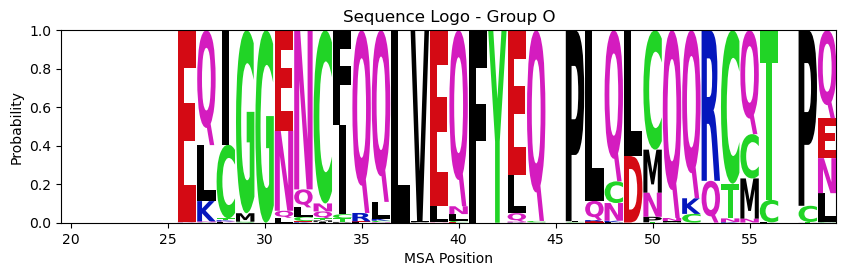

<Figure size 1500x400 with 0 Axes>

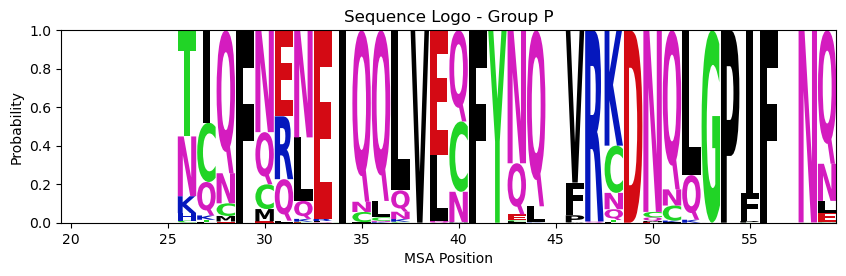

<Figure size 1500x400 with 0 Axes>

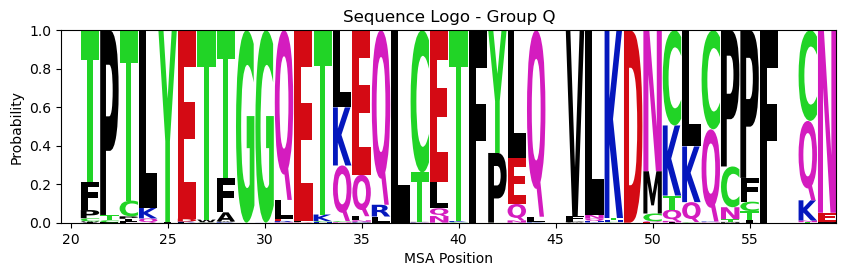

Models saved successfully.


In [6]:
# =============================================================================
# Group-Specific Sequence Analysis
# =============================================================================

group_indices = {
    "N": [],
    "O": [],
    "P": [],
    "Q": []
}

for i, record in enumerate(records):

    seq_id = record.id

    group_label = seq_id[0]

    if group_label in group_indices:

        group_indices[group_label].append(i)

# =============================================================================
# Summary of Group Sizes
# =============================================================================

for group, indices in group_indices.items():

    print(
        f"Group {group}: "
        f"{len(indices)} sequences"
    )

# =============================================================================
# Function to Generate Sequence Logos from Latent Space
# =============================================================================

def generate_group_logo(
    model,
    input_tensor,
    indices,
    amino_acids,
    group_name,
    start=20,
    end=60
):

    model.eval()

    with torch.no_grad():

        latent_vectors = model.encoder(
            input_tensor[indices].to(device)
        )

        mean_latent = latent_vectors.mean(
            dim=0,
            keepdim=True
        )

        decoded = model.decoder(mean_latent)

        probability_distribution = torch.softmax(
            decoded,
            dim=1
        )

    # Convert probabilities to DataFrame
    probability_matrix = (
        probability_distribution
        .squeeze(0)
        .cpu()
        .numpy()
        .T
    )

    probability_df = pd.DataFrame(
        probability_matrix,
        columns=amino_acids
    )

    # Remove gap character for visualization
    probability_df = probability_df.drop(
        columns=["-"]
    )

    # =============================================================================
    # Sequence Logo Visualization
    # =============================================================================

    plt.figure(figsize=(15, 4))

    logomaker.Logo(
        probability_df.iloc[start:end]
    )

    plt.title(
        f"Sequence Logo - Group {group_name}"
    )

    plt.xlabel("MSA Position")
    plt.ylabel("Probability")

    plt.savefig(
        f"../results/logo_group_{group_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# =============================================================================
# Generate Group-Specific Sequence Logos
# =============================================================================

for group_name in ["N", "O", "P", "Q"]:

    generate_group_logo(
        trained_model,
        input_tensor,
        group_indices[group_name],
        amino_acids,
        group_name
    )

# =============================================================================
# Save Trained Models
# =============================================================================

for latent_dim in [8, 4, 2, 1]:

    torch.save(
        all_results[latent_dim]["model"].state_dict(),
        f"../results/model_latent_{latent_dim}.pt"
    )

print("Models saved successfully.")

## Interpretation of Subfamily-Specific Latent Representations

To further investigate the biological information captured by the latent space, separate sequence logos were generated for each protein subgroup (N, O, P, and Q) using the mean latent representation of each group followed by decoding through the trained decoder network.

The resulting sequence logos displayed subgroup-specific conservation patterns and amino acid preferences across multiple alignment positions. While many conserved positions were shared across all groups — reflecting the common structural and functional properties of truncated hemoglobins — several positions showed distinct residue usage and conservation intensity between subfamilies.

For example, some alignment positions were strongly dominated by specific amino acids in one subgroup while exhibiting greater variability in others. These differences suggest that the autoencoder successfully captured subgroup-dependent sequence characteristics within the latent space representation.

Importantly, these patterns emerged without explicit supervision or subgroup labels during training. The model learned these relationships directly from the statistical structure of the multiple sequence alignment, indicating that the latent representations encode biologically meaningful sequence variation in an unsupervised manner.

The generated logos also exhibited coherent and well-defined conservation profiles rather than noisy or random amino acid distributions. This behavior further supports that the autoencoder learned genuine sequence regularities and evolutionary constraints present in the protein family instead of simply memorizing training examples.

Overall, this analysis demonstrates that the learned latent space preserves both globally conserved protein family features and subgroup-specific sequence signatures, highlighting the potential of deep learning approaches for unsupervised protein representation learning, sequence analysis, and biological feature extraction from MSAs.

## Visualization of the Learned Latent Space

To explore how the autoencoder organizes protein sequences internally, a model with a two-dimensional latent space was trained and used to generate sequence embeddings.

For each sequence, the latent tensor produced by the encoder was averaged across alignment positions, resulting in a single 2D embedding vector per protein. These embeddings were then visualized according to their corresponding protein subgroup (N, O, P, or Q).

This analysis enables direct inspection of the geometric organization learned by the autoencoder in an unsupervised setting.

Latent tensor shape: torch.Size([2009, 2, 203])
Sequence embedding shape: torch.Size([2009, 2])
['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


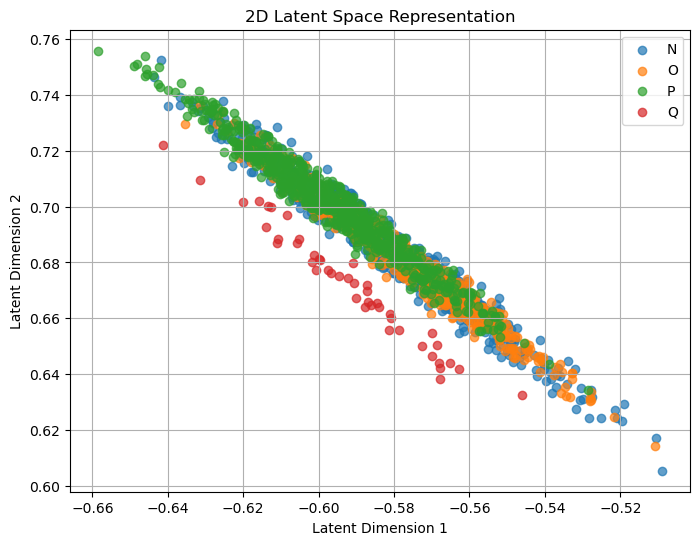

In [7]:
# =============================================================================
# Latent Space Visualization (2D Autoencoder)
# =============================================================================

model_2d = all_results[2]["model"]

model_2d.eval()

# =============================================================================
# Generate Latent Embeddings
# =============================================================================

with torch.no_grad():

    latent_vectors_2d = model_2d.encoder(
        input_tensor.to(device)
    )

print(f"Latent tensor shape: {latent_vectors_2d.shape}")

# =============================================================================
# Sequence-Level Embeddings
# =============================================================================

# Average latent representation across MSA positions
sequence_embeddings = latent_vectors_2d.mean(dim=2)

print(f"Sequence embedding shape: {sequence_embeddings.shape}")

# =============================================================================
# Convert Embeddings to NumPy
# =============================================================================

embeddings_np = (
    sequence_embeddings
    .cpu()
    .numpy()
)

# =============================================================================
# Create Group Labels
# =============================================================================

group_labels = [
    record.id[0]
    for record in records
]

print(group_labels[:10])

# =============================================================================
# 2D Latent Space Visualization
# =============================================================================

plt.figure(figsize=(8, 6))

groups = ["N", "O", "P", "Q"]

for group in groups:

    mask = np.array(group_labels) == group

    plt.scatter(
        embeddings_np[mask, 0],
        embeddings_np[mask, 1],
        label=group,
        alpha=0.7
    )

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title(
    "2D Latent Space Representation"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/latent_space_2d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation of the 2D Latent Space

A two-dimensional autoencoder was trained in order to directly visualize the latent representations learned from the protein sequence alignment.

For each protein sequence, the latent tensor generated by the encoder was averaged across alignment positions, resulting in a single two-dimensional embedding vector per sequence. The resulting embeddings were visualized according to their corresponding protein subgroup (N, O, P, or Q).

The latent space representation revealed a continuous organizational structure learned by the autoencoder. Groups N, O, and P displayed substantial overlap, which is biologically consistent with the evolutionary and structural similarity among these truncated hemoglobin subfamilies.

In contrast, Group Q appeared shifted toward a more distinct region of the latent space, suggesting that the model captured sequence features differentiating this subgroup from the remaining protein families.

The approximately continuous and partially linear organization of the embeddings suggests that a large fraction of the sequence variability can be represented through a reduced set of dominant latent features learned by the autoencoder.

Importantly, these patterns emerged despite the completely unsupervised training procedure. No subgroup labels or evolutionary annotations were provided during training, indicating that the latent space organization arose directly from the statistical structure of the multiple sequence alignment.

Overall, these results demonstrate that the learned latent space captures biologically meaningful sequence relationships and preserves relevant evolutionary information, highlighting the utility of deep learning approaches for unsupervised protein representation learning and embedding analysis.

### PCA-Based Analysis of Latent Representations

To further investigate the structure of the learned latent space, Principal Component Analysis (PCA) was applied to the sequence embeddings generated by the autoencoder with `latent_dim=2`.

Each sequence embedding was obtained by averaging the latent tensor across alignment positions, resulting in a compact vector representation for every protein sequence. PCA was then used to project these embeddings into an orthogonal space and quantify the variance captured by the principal components.

PCA embedding shape: (2009, 2)
Explained variance ratio: [0.9851639  0.01483606]


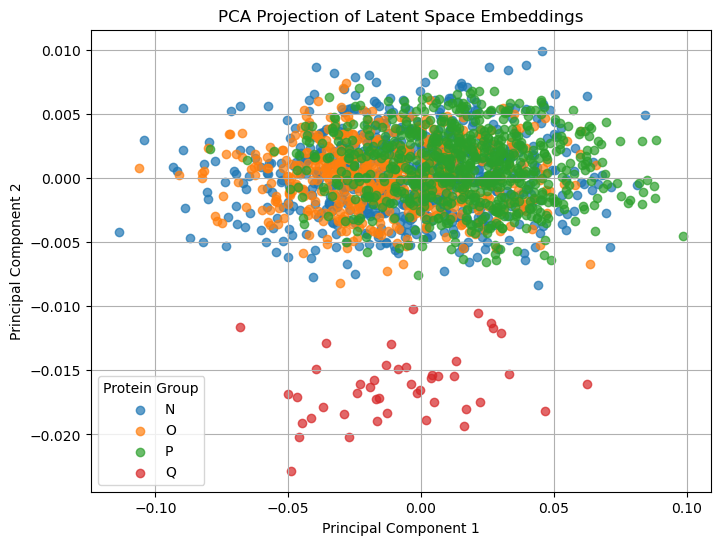

In [8]:
# =============================================================================
# PCA Analysis of Latent Space Embeddings
# =============================================================================

# Apply PCA to latent embeddings
pca = PCA(n_components=2)

pca_embeddings = pca.fit_transform(
    embeddings_np
)

print(f"PCA embedding shape: {pca_embeddings.shape}")

# Explained variance
explained_variance = pca.explained_variance_ratio_

print(
    "Explained variance ratio:",
    explained_variance
)

# =============================================================================
# PCA Visualization
# =============================================================================

plt.figure(figsize=(8, 6))

groups = ["N", "O", "P", "Q"]

for group in groups:

    mask = np.array(group_labels) == group

    plt.scatter(
        pca_embeddings[mask, 0],
        pca_embeddings[mask, 1],
        label=group,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title(
    "PCA Projection of Latent Space Embeddings"
)

plt.legend(title="Protein Group")

plt.grid(True)

plt.savefig(
    "../results/pca_latent_space.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### PCA-Based Interpretation of the Latent Space

Principal Component Analysis (PCA) was applied to the latent embeddings generated by the autoencoder in order to investigate the global organization of the learned representation space.

The PCA projection revealed that the first principal component captures the vast majority of the variance within the latent space, while the second component contributes only marginally. This indicates that the autoencoder learned a highly structured and low-dimensional representation of the protein family.

The resulting visualization shows that sequences belonging to groups N, O and P occupy partially overlapping regions of the latent space, reflecting their evolutionary and structural similarities. In contrast, sequences from group Q appear shifted toward a more distinct region, suggesting that the model successfully captures biologically meaningful differences between subfamilies.

The approximately continuous organization observed in the PCA projection suggests that the latent space encodes gradual sequence variation rather than discrete clustering alone. This behavior is consistent with the ability of autoencoders to learn compact representations that preserve underlying biological relationships in an unsupervised manner.

Overall, these results demonstrate that the learned latent embeddings retain biologically relevant information and organize protein sequences according to shared structural and evolutionary features.

# Protein Sequence Generation from the Latent Space

To explore the generative capabilities of the learned latent space, new protein sequences were generated using two different strategies:

1. Random sampling from the latent distribution learned by the autoencoder.
2. Latent space interpolation between embeddings of real protein sequences.

These experiments evaluate whether the learned latent representations encode biologically meaningful structure and whether nearby regions of the latent space correspond to plausible protein sequences.

In [9]:
# =============================================================================
# Sequence Generation from the Latent Space
# =============================================================================

best_model = all_results[8]["model"]

best_model.eval()

# =============================================================================
# Obtain Latent Representations
# =============================================================================

with torch.no_grad():

    latent_vectors = best_model.encoder(
        input_tensor.to(device)
    )

print(f"Latent tensor shape: {latent_vectors.shape}")

# =============================================================================
# PART A — Random Sampling from Latent Space
# =============================================================================

# Estimate latent distribution
latent_mean = latent_vectors.mean(dim=0)

latent_std = latent_vectors.std(dim=0)

print(f"Latent mean shape: {latent_mean.shape}")
print(f"Latent std shape: {latent_std.shape}")

# Sample new latent representation
sampled_latent = torch.normal(
    mean=latent_mean,
    std=latent_std
)

sampled_latent = sampled_latent.unsqueeze(0)

print(f"Sampled latent shape: {sampled_latent.shape}")

# Decode generated latent vector
with torch.no_grad():

    generated_output = best_model.decoder(
        sampled_latent
    )

generated_output = (
    generated_output
    .squeeze(0)
    .cpu()
)

generated_sequence = tensor_to_sequence(
    generated_output,
    idx_to_aa
)

print("Generated sequence (random sampling):\n")
print(generated_sequence)

# Save generated sequence
with open(
    "../results/generated_sequence_sampling.fasta",
    "w"
) as f:

    f.write(">generated_sampling\n")
    f.write(generated_sequence + "\n")

# =============================================================================
# PART B — Latent Space Interpolation
# =============================================================================

# Select two real protein sequences
seq1 = input_tensor[0].unsqueeze(0).to(device)

seq2 = input_tensor[100].unsqueeze(0).to(device)

# Encode sequences into latent space
with torch.no_grad():

    z1 = best_model.encoder(seq1)

    z2 = best_model.encoder(seq2)

# Interpolate between latent representations
alpha = 0.5

interpolated_z = (
    alpha * z1 +
    (1 - alpha) * z2
)

# Decode interpolated latent vector
with torch.no_grad():

    interpolated_output = best_model.decoder(
        interpolated_z
    )

interpolated_output = (
    interpolated_output
    .squeeze(0)
    .cpu()
)

interpolated_sequence = tensor_to_sequence(
    interpolated_output,
    idx_to_aa
)

print("\nGenerated sequence (latent interpolation):\n")
print(interpolated_sequence)

# Save interpolated sequence
with open(
    "../results/generated_sequence_interpolation.fasta",
    "w"
) as f:

    f.write(">generated_interpolation\n")
    f.write(interpolated_sequence + "\n")

Latent tensor shape: torch.Size([2009, 8, 203])
Latent mean shape: torch.Size([8, 203])
Latent std shape: torch.Size([8, 203])
Sampled latent shape: torch.Size([1, 8, 203])
Generated sequence (random sampling):

NIVW-----------------------NENLNMMLTNDNMSFYMG-LKQLPSINTNFASS-WWTVSSVNGKISNFVHPPL-LSSS------SYTSPS-VHFFTTSMHVPPWLTGSHHNV-VMSTWSEMLINT--------------LVPSNT--TLKWNLTMTGTMSMDMSKV------------------------------

Generated sequence (latent interpolation):

KTI----------------------HSKLGGEMAMEVAVNTFYEK-NNADKQTVCFF-ESV--DMNVQNKQQPMFTTVDV-GGVT------PYSGKT-----DMSAHKLNSLQKGHFDA-STEVLATTLQGL--------------GSSMMN--NTEMTVTLNVTKKMLVEV-------------------------------


## Generative Exploration of the Latent Space

To evaluate whether the learned latent space could support protein sequence generation, two generative strategies were explored: random latent sampling and interpolation between embeddings of real protein sequences.

### Random Latent Sampling

A new latent representation was generated by sampling from the empirical mean and standard deviation of the latent space learned by the autoencoder. The sampled latent vector was then decoded into a novel protein sequence.

The generated sequence displayed structural characteristics resembling aligned globin-like proteins, including conserved gap patterns and sequence organization. However, similarity searches against known protein databases did not produce significant BLAST hits.

This result suggests that fully random sampling may generate latent representations located outside densely populated biologically meaningful regions of the latent space. As a consequence, some decoded sequences may not correspond to naturally occurring or structurally plausible proteins.

This behavior highlights a known limitation of standard autoencoders: unlike variational autoencoders (VAEs), the latent space is not explicitly regularized to ensure smooth biological continuity across all regions.

### Latent Space Interpolation

A second generation strategy was based on interpolation between latent embeddings of two real protein sequences. The midpoint between both latent representations was decoded to generate a new sequence.

In contrast to random sampling, the interpolated sequence produced multiple significant BLAST hits against proteins annotated as truncated hemoglobins and globin-related proteins. The resulting alignments showed strong coverage and biologically meaningful sequence identity values, indicating that the generated sequence preserved key characteristics of the protein family.

These results suggest that interpolation between embeddings of real sequences remains within biologically coherent regions of the latent space. The generated sequence retained structural and evolutionary patterns characteristic of truncated globins and was recognized as belonging to related protein families.

### Overall Interpretation

Together, these experiments demonstrate that the learned latent space contains biologically relevant structure rather than arbitrary numerical representations.

Random sampling may access low-density regions that do not correspond to realistic protein sequences, whereas interpolation between real latent embeddings generates sequences that remain compatible with naturally occurring proteins.

Overall, the results highlight the potential of deep learning latent representations for protein sequence modeling, generative exploration, and unsupervised representation learning in computational biology.

# Learned Amino Acid Embeddings

To investigate whether the autoencoder learned biologically meaningful residue representations, latent embeddings were extracted for each amino acid directly from the trained encoder.

The embeddings were computed by averaging latent activations associated with each amino acid across the full multiple sequence alignment (MSA). Principal Component Analysis (PCA) was then applied to project the embeddings into two dimensions for visualization and comparison.

The same procedure was repeated for an untrained model in order to compare learned versus randomly initialized latent representations.

Trained model loaded successfully.
Encoded tensor shape: torch.Size([2009, 8, 203])
Amino acid embedding tensor shape: torch.Size([8, 21])
Amino acid counts shape: torch.Size([21])
Embedding matrix shape: (21, 8)
PCA embedding shape: (21, 2)


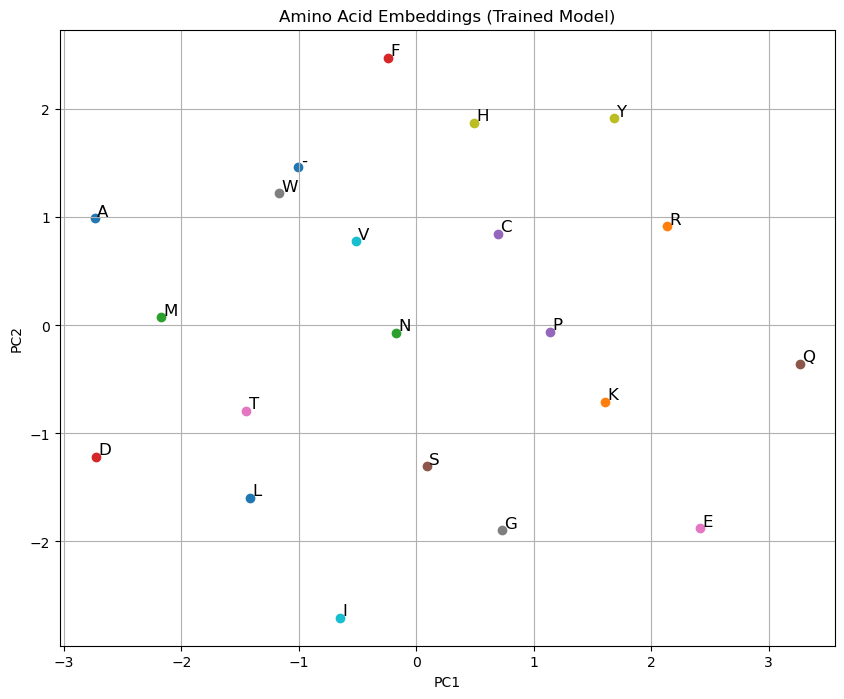

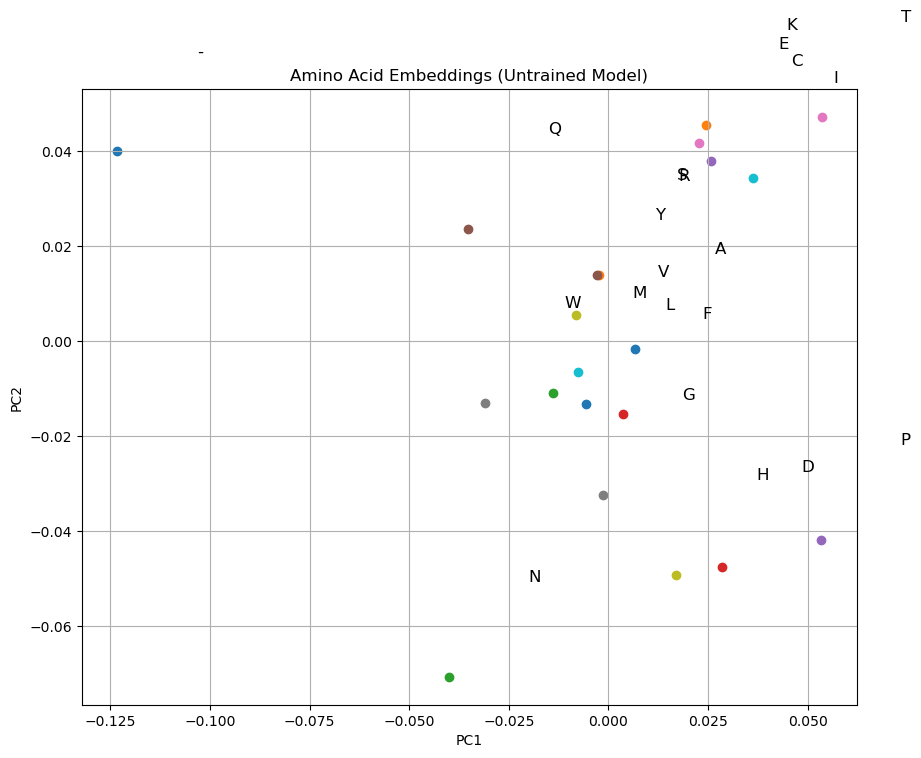

In [10]:
# =============================================================================
# Amino Acid Embedding Analysis
# =============================================================================

# =============================================================================
# Load Trained Model
# =============================================================================

best_model = MSAAutoencoder(
    seq_length=L,
    latent_dim=8
).to(device)

best_model.load_state_dict(
    torch.load(
        "../results/model_latent_8.pt",
        map_location=device
    )
)

best_model.eval()

print("Trained model loaded successfully.")

# =============================================================================
# Extract Latent Representations
# =============================================================================

with torch.no_grad():

    encoded = best_model.encoder(
        input_tensor.to(device)
    ).cpu()

print(f"Encoded tensor shape: {encoded.shape}")

# =============================================================================
# Compute Amino Acid Embeddings
# =============================================================================

amino_acid_embeddings = torch.einsum(
    "ndl,nsl->ds",
    encoded,
    input_tensor
)

print(
    f"Amino acid embedding tensor shape: "
    f"{amino_acid_embeddings.shape}"
)

# =============================================================================
# Normalize Embeddings
# =============================================================================

aa_counts = input_tensor.sum(dim=(0, 2))

print(f"Amino acid counts shape: {aa_counts.shape}")

amino_acid_embeddings = (
    amino_acid_embeddings / aa_counts
)

# =============================================================================
# PCA Projection
# =============================================================================

embedding_matrix = (
    amino_acid_embeddings
    .T
    .numpy()
)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

pca = PCA(n_components=2)

embedding_pca = pca.fit_transform(
    embedding_matrix
)

print(f"PCA embedding shape: {embedding_pca.shape}")

# =============================================================================
# Plot Trained Embeddings
# =============================================================================

plt.figure(figsize=(10, 8))

for i, aa in enumerate(amino_acids):

    x = embedding_pca[i, 0]
    y = embedding_pca[i, 1]

    plt.scatter(x, y)

    plt.text(
        x + 0.02,
        y + 0.02,
        aa,
        fontsize=12
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Amino Acid Embeddings (Trained Model)"
)

plt.grid(True)

plt.savefig(
    "../results/amino_acid_embeddings_trained.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# Untrained Model Embeddings
# =============================================================================

untrained_model = MSAAutoencoder(
    seq_length=L,
    latent_dim=8
).to(device)

untrained_model.eval()

with torch.no_grad():

    untrained_encoded = untrained_model.encoder(
        input_tensor.to(device)
    ).cpu()

# Compute embeddings
untrained_embeddings = torch.einsum(
    "ndl,nsl->ds",
    untrained_encoded,
    input_tensor
)

# Normalize
untrained_embeddings = (
    untrained_embeddings / aa_counts
)

# PCA projection
untrained_matrix = (
    untrained_embeddings
    .T
    .numpy()
)

pca_untrained = PCA(n_components=2)

untrained_pca = pca_untrained.fit_transform(
    untrained_matrix
)

# =============================================================================
# Plot Untrained Embeddings
# =============================================================================

plt.figure(figsize=(10, 8))

for i, aa in enumerate(amino_acids):

    x = untrained_pca[i, 0]
    y = untrained_pca[i, 1]

    plt.scatter(x, y)

    plt.text(
        x + 0.02,
        y + 0.02,
        aa,
        fontsize=12
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Amino Acid Embeddings (Untrained Model)"
)

plt.grid(True)

plt.savefig(
    "../results/amino_acid_embeddings_untrained.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Learned Amino Acid Embeddings

Latent representations generated by the encoder were used to derive embeddings for the 20 amino acids and the alignment gap token.

The embeddings were computed by averaging latent activations associated with each residue across the multiple sequence alignment. Principal Component Analysis (PCA) was then applied to project the embeddings into a two-dimensional space for visualization.

### Comparison Between Untrained and Trained Models

### Untrained Model

In the untrained model, amino acid embeddings appeared distributed in an essentially random manner, without biologically meaningful organization or clustering.

Residues sharing similar physicochemical properties — such as Aspartate (D) and Glutamate (E), or Leucine (L) and Valine (V) — did not display consistent spatial proximity. The observed variation reflected only the random initialization of the network weights.

This indicates that prior to training, the model contains no information regarding biochemical relationships between amino acids and treats each residue independently.

### Trained Model

After training on the truncated hemoglobin multiple sequence alignment, the latent embedding space became substantially more organized and biologically coherent.

Several meaningful residue groupings emerged naturally from the unsupervised learning process:

- Hydrophobic and aliphatic residues such as Leucine (L), Valine (V), and Phenylalanine (F) clustered together.
- Aromatic amino acids including Tyrosine (Y) and Tryptophan (W) occupied nearby regions of the latent space.
- Charged residues such as Aspartate (D), Glutamate (E), and Arginine (R) became clearly separated from hydrophobic groups.
- Structurally unique residues including Glycine (G) and Proline (P) occupied more isolated positions, consistent with their distinctive conformational roles in proteins.

These patterns suggest that the autoencoder successfully learned evolutionary and biochemical regularities directly from the sequence alignment data.

### Overall Interpretation

The comparison between trained and untrained embeddings demonstrates that the autoencoder transformed an initially random latent space into a biologically informative representation space.

The learned embeddings captured similarities related to amino acid chemistry, structural behavior, and evolutionary substitution patterns, despite the absence of explicit supervision during training.

Overall, these results highlight the ability of deep learning autoencoders to generate compact and biologically meaningful protein representations, illustrating their potential utility for protein sequence modeling, embedding learning, and representation analysis in computational biology and AI-driven biotechnology.